# RetailPulse — Exploratory Data Analysis


## 1. Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('libraries loaded')

libraries loaded


## 2. Load Datasets

In [2]:
df_sales     = pd.read_csv('../data/raw/online_retail_II.csv', encoding='utf-8', low_memory=False)
df_churn     = pd.read_csv('../data/raw/online_retail_customer_churn.csv')
df_inventory = pd.read_csv('../data/raw/retail_store_inventory.csv')

# parse dates
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])
df_inventory['Date']    = pd.to_datetime(df_inventory['Date'])

print('Sales:    ', df_sales.shape)
print('Churn:    ', df_churn.shape)
print('Inventory:', df_inventory.shape)

Sales:     (1067371, 8)
Churn:     (1000, 15)
Inventory: (73100, 15)


## 3. Basic Info

In [3]:
print('--- Sales ---')
display(df_sales.head())
print(df_sales.dtypes)

--- Sales ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [4]:
print('--- Churn ---')
display(df_churn.head())
print(df_churn.dtypes)

--- Churn ---


,Customer_ID,Age,Gender,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,Last_Purchase_Days_Ago,Email_Opt_In,Promotion_Response,Target_Churn
0,1,62,Other,45.15,5892.58,5,22,453.80,2,0,3,129,True,Responded,True
1,2,65,Male,79.51,9025.47,13,77,22.90,2,2,3,227,False,Responded,False
2,3,18,Male,29.19,618.83,13,71,50.53,5,2,2,283,False,Responded,True
3,4,21,Other,79.63,9110.30,3,33,411.83,5,3,5,226,True,Ignored,True
4,5,21,Other,77.66,5390.88,15,43,101.19,3,0,5,242,False,Unsubscribed,False


Customer_ID                     int64
Age                             int64
Gender                         object
Annual_Income                 float64
Total_Spend                   float64
Years_as_Customer               int64
Num_of_Purchases                int64
Average_Transaction_Amount    float64
Num_of_Returns                  int64
Num_of_Support_Contacts         int64
Satisfaction_Score              int64
Last_Purchase_Days_Ago          int64
Email_Opt_In                     bool
Promotion_Response             object
Target_Churn                     bool
dtype: object


In [5]:
print('--- Inventory ---')
display(df_inventory.head())
print(df_inventory.dtypes)

--- Inventory ---


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition             object
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                   object
dtype: object


## 4. Missing Values

In [6]:
def missing_report(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df)) * 100
    out  = pd.DataFrame({'count': miss, 'percent': pct.round(2)})
    out  = out[out['count'] > 0].sort_values('percent', ascending=False)
    print(f'\n{name}')
    if out.empty:
        print('  no missing values')
    else:
        print(out)

missing_report(df_sales,     'Sales')
missing_report(df_churn,     'Churn')
missing_report(df_inventory, 'Inventory')


Sales
              count  percent
Customer ID  243007    22.77
Description    4382     0.41

Churn
  no missing values

Inventory
  no missing values


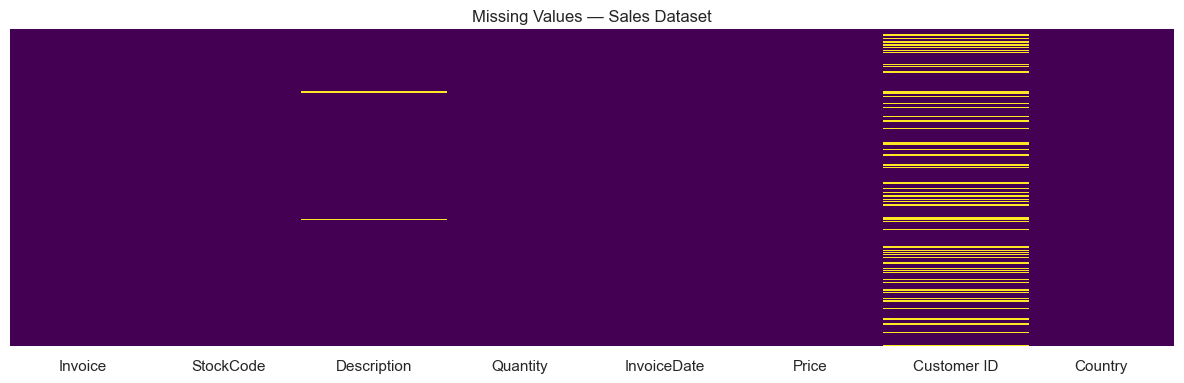

In [7]:
# visualize missing values for the sales dataset (it has the most nulls)
plt.figure(figsize=(12, 4))
sns.heatmap(df_sales.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values — Sales Dataset')
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=150)
plt.show()

## 5. Distribution Analysis — Sales

In [8]:
# drop rows with missing customer id, negative qty (returns) and zero price
df_valid = df_sales[
    (df_sales['Quantity'] > 0) &
    (df_sales['Price'] > 0) &
    (df_sales['Customer ID'].notna())
].copy()

df_valid['Revenue'] = df_valid['Quantity'] * df_valid['Price']

print('valid rows:', len(df_valid))
print('removed:', len(df_sales) - len(df_valid))
print('total revenue: £', round(df_valid['Revenue'].sum(), 2))

valid rows: 805549
removed: 261822
total revenue: £ 17743429.18


In [9]:
# numeric column distributions
num_cols = df_valid.select_dtypes(include=np.number).columns.tolist()
print('numeric cols:', num_cols)

numeric cols: ['Quantity', 'Price', 'Customer ID', 'Revenue']


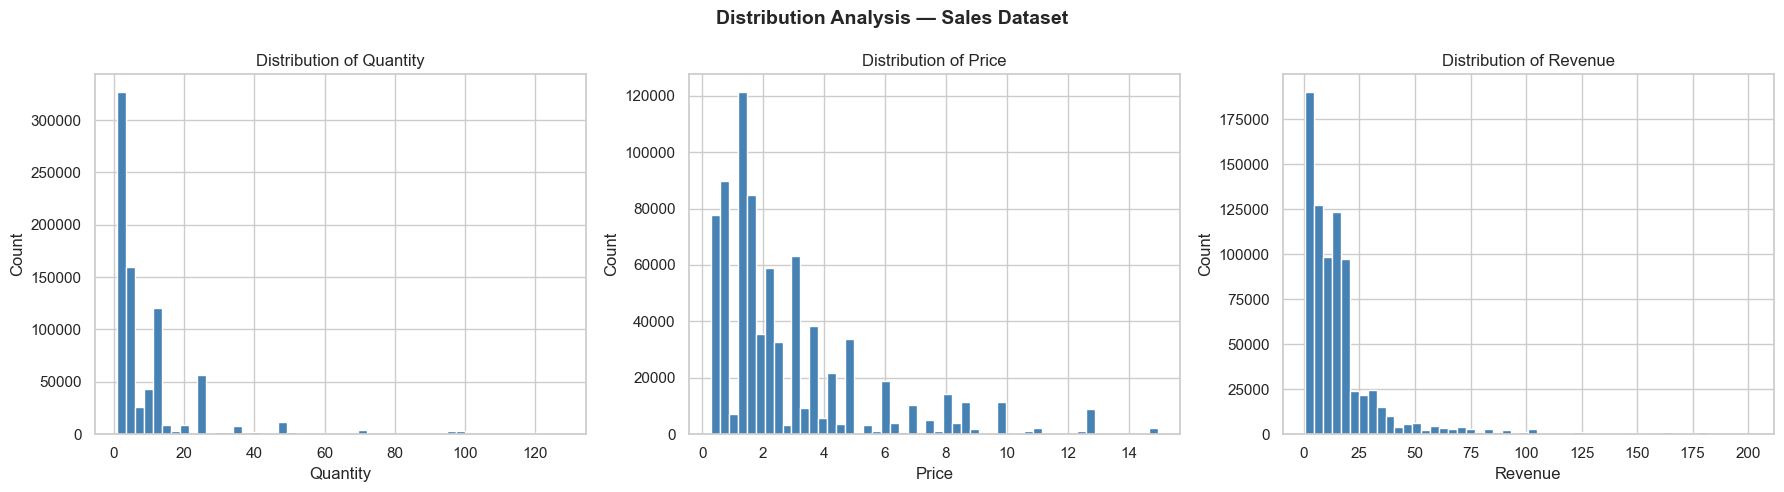

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Quantity', 'Price', 'Revenue']):
    data = df_valid[col].dropna()
    data = data[data.between(data.quantile(0.01), data.quantile(0.99))]  # remove outliers
    ax.hist(data, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distribution Analysis — Sales Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/distribution_sales.png', dpi=150)
plt.show()

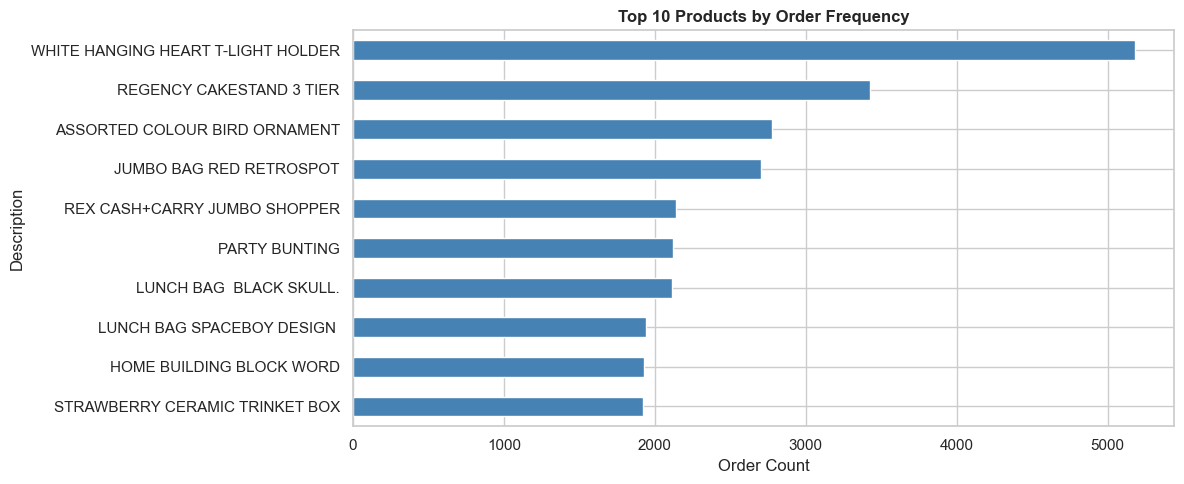

In [11]:
# top 10 products by order count
top_products = df_valid['Description'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_products.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Products by Order Frequency', fontweight='bold')
plt.xlabel('Order Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_products.png', dpi=150)
plt.show()

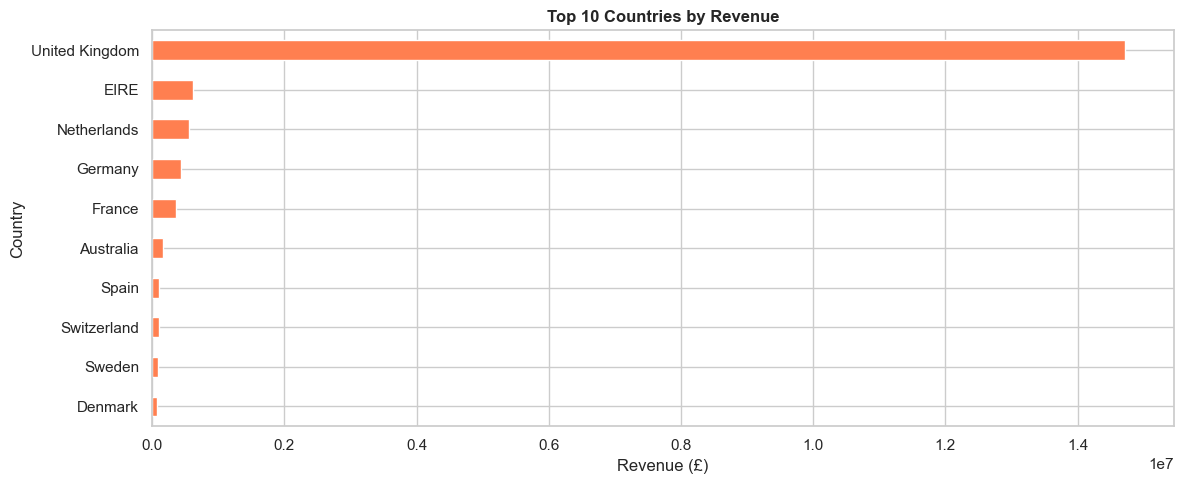

In [12]:
# top 10 countries by revenue
country_rev = df_valid.groupby('Country')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(12, 5))
country_rev.sort_values().plot(kind='barh', color='coral', edgecolor='white')
plt.title('Top 10 Countries by Revenue', fontweight='bold')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/figures/top_countries.png', dpi=150)
plt.show()

## 6. Monthly Sales Trend

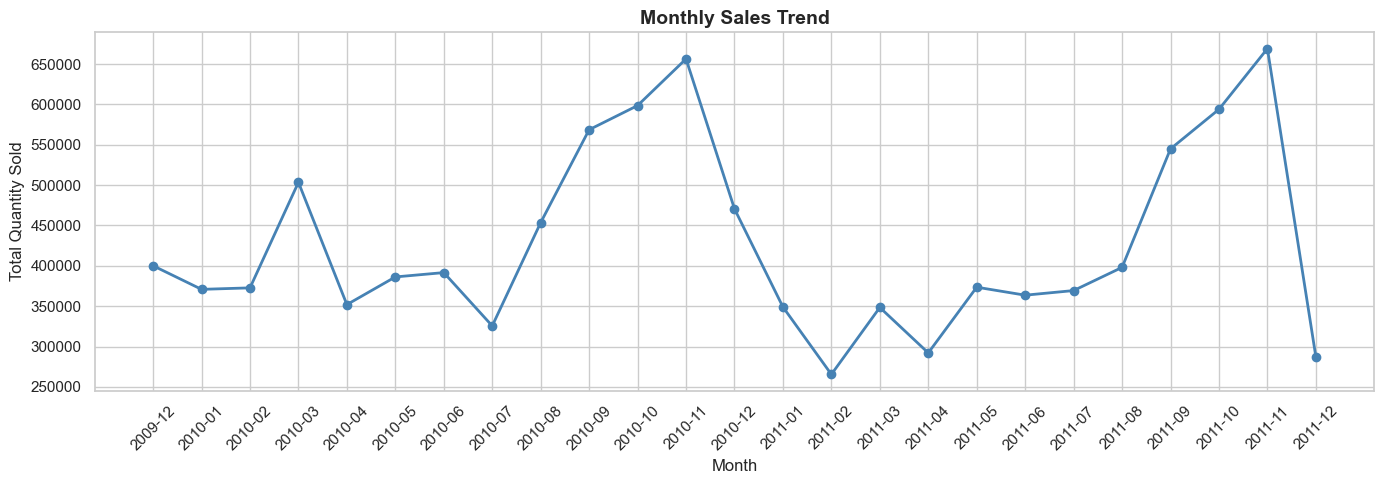

In [13]:
df_valid['YearMonth'] = df_valid['InvoiceDate'].dt.to_period('M')
monthly = df_valid.groupby('YearMonth')['Quantity'].sum().reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['Quantity'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/monthly_sales_trend.png', dpi=150)
plt.show()

## 7. Distribution Analysis — Churn

In [14]:
num_cols_churn = df_churn.select_dtypes(include=np.number).columns.tolist()
print('numeric cols:', num_cols_churn)
print('churn rate:', round(df_churn['Target_Churn'].mean() * 100, 1), '%')

numeric cols: ['Customer_ID', 'Age', 'Annual_Income', 'Total_Spend', 'Years_as_Customer', 'Num_of_Purchases', 'Average_Transaction_Amount', 'Num_of_Returns', 'Num_of_Support_Contacts', 'Satisfaction_Score', 'Last_Purchase_Days_Ago']
churn rate: 52.6 %


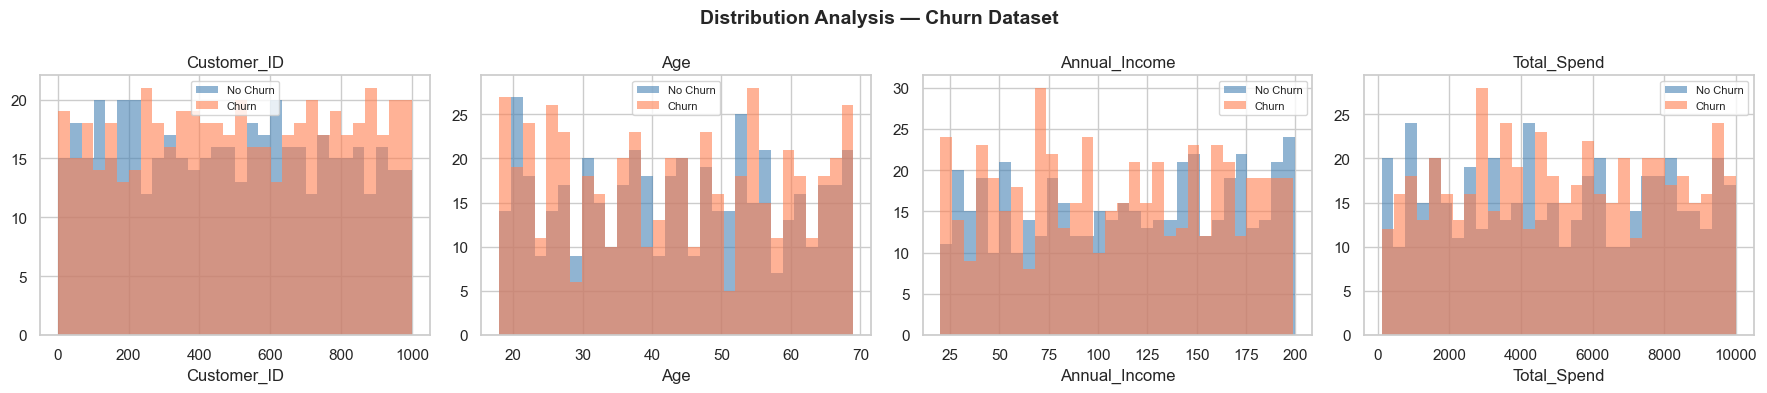

In [15]:
# plot first 4 numeric features
cols_to_plot = num_cols_churn[:4]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(18, 4))

for ax, col in zip(axes, cols_to_plot):
    for val, label, color in [(False, 'No Churn', 'steelblue'), (True, 'Churn', 'coral')]:
        ax.hist(df_churn[df_churn['Target_Churn'] == val][col],
                bins=30, alpha=0.6, label=label, color=color, edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribution Analysis — Churn Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/distribution_churn.png', dpi=150)
plt.show()

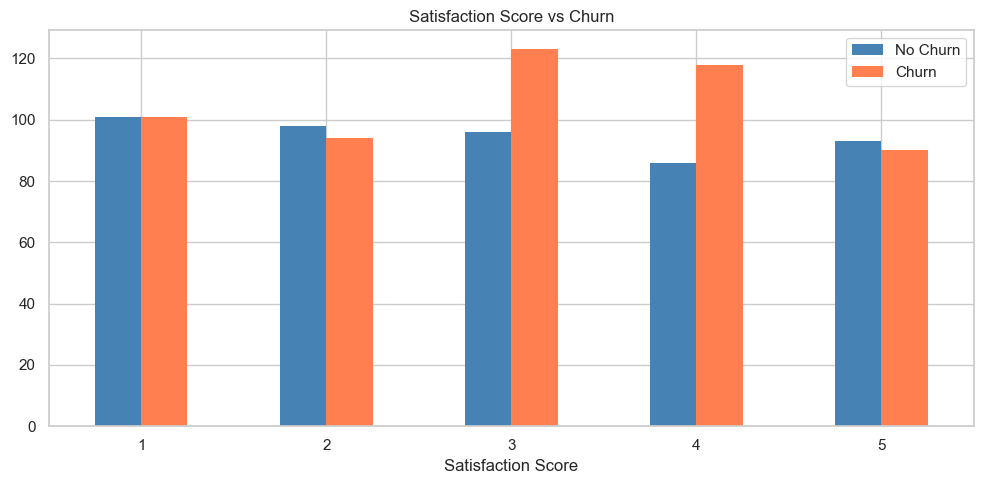

In [16]:
# satisfaction score vs churn — interesting to see if low satisfaction = more churn
sat = df_churn.groupby(['Satisfaction_Score', 'Target_Churn']).size().unstack(fill_value=0)
sat.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'], edgecolor='none')
plt.title('Satisfaction Score vs Churn')
plt.xlabel('Satisfaction Score')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('../reports/figures/satisfaction_vs_churn.png', dpi=150)
plt.show()

## 8. Distribution Analysis — Inventory

In [17]:
num_cols_inv = df_inventory.select_dtypes(include=np.number).columns.tolist()
print('numeric cols:', num_cols_inv)

numeric cols: ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']


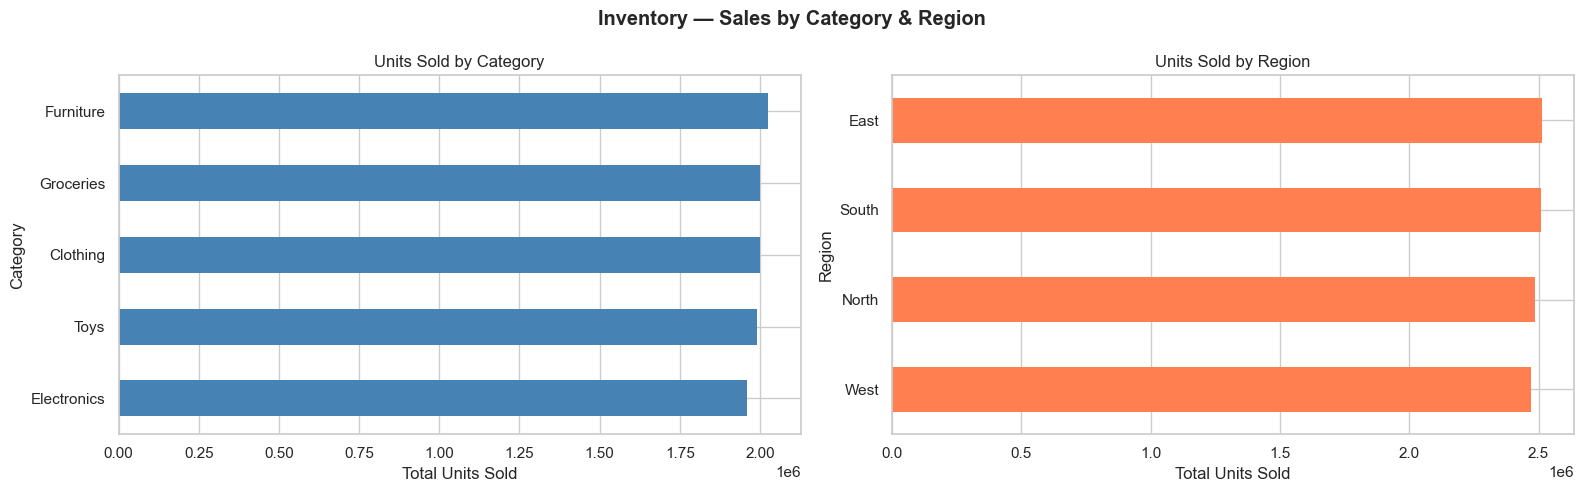

In [18]:
# units sold by category and region
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_inventory.groupby('Category')['Units Sold'].sum().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Units Sold by Category')
axes[0].set_xlabel('Total Units Sold')

df_inventory.groupby('Region')['Units Sold'].sum().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title('Units Sold by Region')
axes[1].set_xlabel('Total Units Sold')

plt.suptitle('Inventory — Sales by Category & Region', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/inventory_category_region.png', dpi=150)
plt.show()

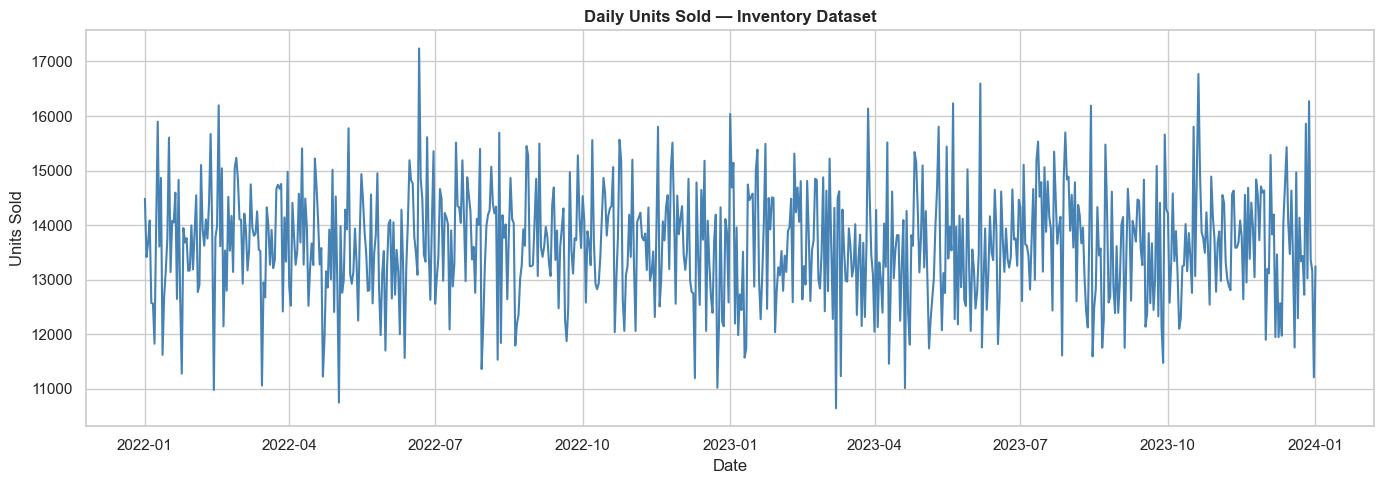

In [19]:
# daily inventory trend
daily_inv = df_inventory.groupby('Date')['Units Sold'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_inv.index, daily_inv.values, color='steelblue', linewidth=1.5)
plt.title('Daily Units Sold — Inventory Dataset', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig('../reports/figures/inventory_daily_trend.png', dpi=150)
plt.show()

## 9. Correlation Heatmap

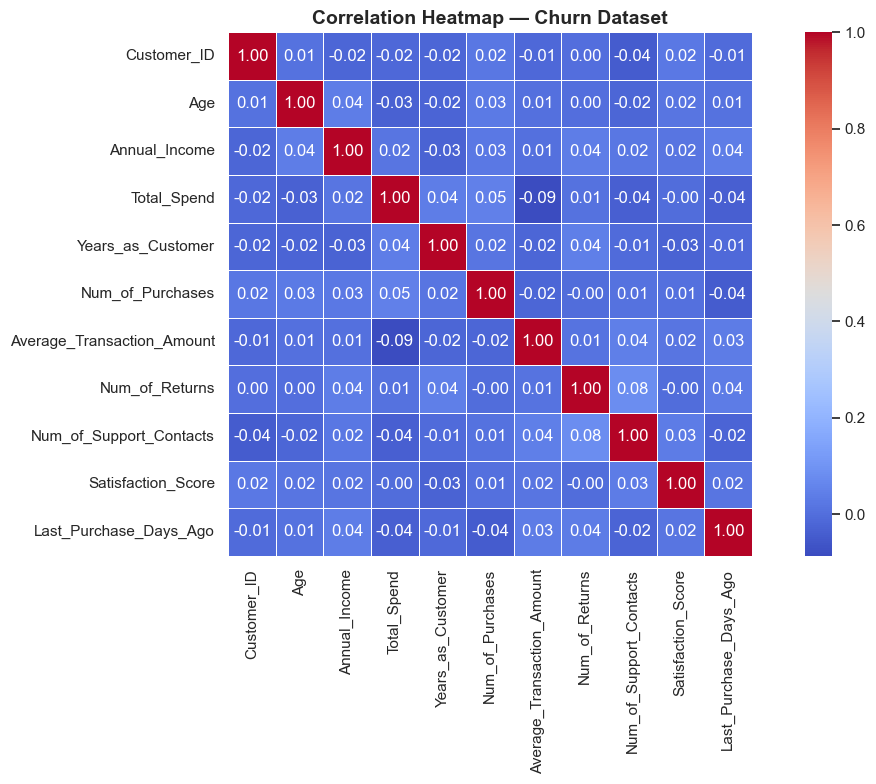

In [20]:
# churn dataset
corr_churn = df_churn.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_churn, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Churn Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_churn.png', dpi=150)
plt.show()

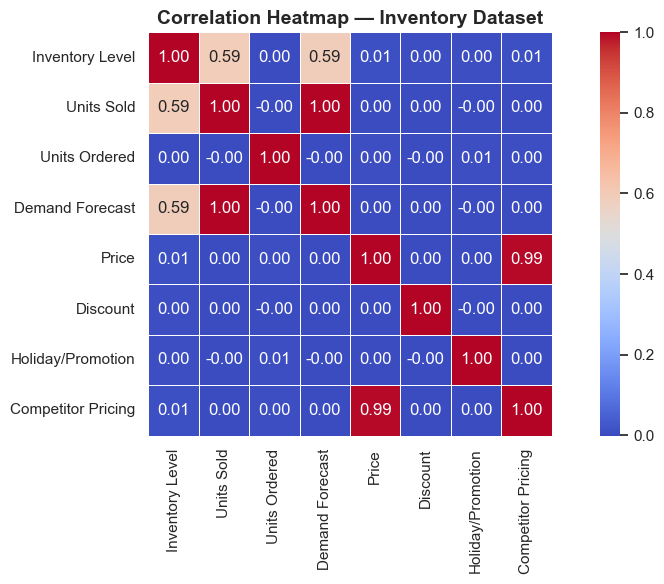

In [21]:
# inventory dataset
corr_inv = df_inventory.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_inv, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Inventory Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_inventory.png', dpi=150)
plt.show()

## 10. Summary Statistics

In [22]:
print('===== SALES =====')
display(df_valid[['Quantity', 'Price', 'Revenue']].describe().round(2))

===== SALES =====


,Quantity,Price,Revenue
count,805549.00,805549.00,805549.00
mean,13.29,3.21,22.03
std,143.63,29.20,224.04
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,5.00,1.95,11.85
75%,12.00,3.75,19.50
max,80995.00,10953.50,168469.60


In [23]:
print('===== CHURN =====')
display(df_churn.describe().round(2))

===== CHURN =====


,Customer_ID,Age,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,Last_Purchase_Days_Ago
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,43.27,111.96,5080.79,9.73,49.46,266.88,4.61,1.93,2.97,182.89
std,288.82,15.24,52.84,2862.12,5.54,28.54,145.87,2.90,1.40,1.39,104.39
min,1.00,18.00,20.01,108.94,1.00,1.00,10.46,0.00,0.00,1.00,1.00
25%,250.75,30.00,67.80,2678.68,5.00,25.00,139.68,2.00,1.00,2.00,93.00
50%,500.50,43.00,114.14,4986.20,9.00,49.00,270.10,5.00,2.00,3.00,180.50
75%,750.25,56.00,158.45,7606.47,14.00,74.00,401.60,7.00,3.00,4.00,274.00
max,1000.00,69.00,199.73,9999.64,19.00,99.00,499.57,9.00,4.00,5.00,364.00


In [24]:
print('===== INVENTORY =====')
display(df_inventory.describe().round(2))

===== INVENTORY =====


,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.00,73100.00,73100.00,73100.00,73100.00,73100.00,73100.0,73100.00
mean,2022-12-31 23:59:59.999999744,274.47,136.46,110.00,141.49,55.14,10.01,0.5,55.15
min,2022-01-01 00:00:00,50.00,0.00,20.00,-9.99,10.00,0.00,0.0,5.03
25%,2022-07-02 00:00:00,162.00,49.00,65.00,53.67,32.65,5.00,0.0,32.68
50%,2023-01-01 00:00:00,273.00,107.00,110.00,113.02,55.05,10.00,0.0,55.01
75%,2023-07-03 00:00:00,387.00,203.00,155.00,208.05,77.86,15.00,1.0,77.82
max,2024-01-01 00:00:00,500.00,499.00,200.00,518.55,100.00,20.00,1.0,104.94
std,NaN,129.95,108.92,52.28,109.25,26.02,7.08,0.5,26.19


In [25]:
# save cleaned sales data for next step
os.makedirs('../data/interim', exist_ok=True)
df_valid.to_csv('../data/interim/retail_valid_transactions.csv', index=False)
print('saved:', len(df_valid), 'rows to data/interim/retail_valid_transactions.csv')

saved: 805549 rows to data/interim/retail_valid_transactions.csv
